In [2]:
print('Running imports...')

import sys
import torch # long
import os
import numpy as np
import lightning as L
import xarray as xr
from models.model import Wang2024
from lightning.pytorch import loggers, seed_everything

import wandb
from models.lightning import LitCNN_regression, AttributableTrainer
from models.losses import get_loss
import random
import matplotlib
from models.data import get_input_data_from_wandb_logger
from models.model import get_model
from models.callbacks import LogIndividualScores
import argparse
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
# matplotlib.use('tkagg')



seed_everything(42, workers=True)

Seed set to 42


Running imports...


42

In [3]:
wandb_logger = loggers.WandbLogger(project="Predict-rain-WNorway_multidays", 
                                    save_dir="/Data/gfi/users/rogui7909/wanbd_logs/",
                                    dir="/Data/gfi/users/rogui7909/wanbd_logs/wandb", )

wandb_logger.experiment # Initialize wandb


if wandb_logger.experiment.config['num_days_predictant']>1:
    wandb_logger.experiment.config['LSTM_sequence'] = True

train_loader, valid_loader, test_loader, ds_test = get_input_data_from_wandb_logger(wandb_logger)
            
callbacks=[EarlyStopping(monitor="val/loss", mode="min"), LogIndividualScores()]
wandb_logger.experiment.config['loss_fn'] = 'asymetric_mse'
trainer = AttributableTrainer(limit_train_batches=100, 
                                max_epochs=wandb_logger.experiment.config['num_epochs'], 
                                logger=wandb_logger, 
                                log_every_n_steps=1, default_root_dir="/Data/gfi/users/rogui7909/lightning_checkpoint/",
                                callbacks=callbacks, deterministic=True,
                                accelerator="gpu", devices=1,
                                gradient_clip_val=wandb_logger.experiment.config['gradient_clip_val'])

wandb_logger.experiment.config['num_classes'] = wandb_logger.experiment.config['num_days_predicted']
wandb_logger.experiment.config['num_channels'] = len(wandb_logger.experiment.config['input_variable'])

NN = get_model(wandb_logger)

loss = get_loss(wandb_logger.experiment.config['loss_fn'])


model = LitCNN_regression(NN, 
                          learning_rate=wandb_logger.experiment.config['learning_rate'], 
                          lr_scheduler =wandb_logger.experiment.config['lr_scheduler'],
                          loss_fn = loss)

print('Model init')
trainer.fit(model, train_loader, valid_loader)


model.eval()
with torch.no_grad():
    trainer.test(model, dataloaders=test_loader)

wandb: Currently logged in as: rguilcas (rguilcas-university-of-bergen) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


Data ready:
    Image size: 4096 (128x32)
    Input data: u850, v850, w850, z500
    6 Past days used for prediction
    5 Predicted days for future rainfall


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Model init


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name    | Type              | Params | Mode 
------------------------------------------------------
0 | model   | CNN_LSTM_Model    | 26.3 M | train
1 | loss_fn | AsymmetricMSELoss | 0      | train
------------------------------------------------------
26.3 M    Trainable params
0         Non-trainable params
26.3 M    Total params
105.104   Total estimated model params size (MB)
21        Modules in train mode
0         Modules in eval mode


...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=50` reached.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/felles_gfi/felles_gfi_users/rogui7909/miniforge3/envs/robin/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=71` in the `DataLoader` to improve performance.


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test/loss           22.479982376098633
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


In [4]:
targets = xr.DataArray(model.test_true_values, dims=['time','day'])
preds = xr.DataArray(model.test_pred, dims=['time','day'])

quantiles = targets.quantile(np.arange(0,1+1e-9,.01), dim='time')
quantiles_pred = preds.quantile(np.arange(0,1+1e-9,.01), dim='time')


TP = ((targets>quantiles)&(preds>quantiles)).sum('time')
predicted = ((preds>quantiles)).sum('time')
truth = ((targets>quantiles)).sum('time')
precision = TP/predicted
recall = TP/truth
precision=precision.where(precision.notnull(), 0)
recall=recall.where(recall.notnull(), 0)
f1= 2*precision*recall/(precision+recall)
f1=f1.where(f1.notnull(), 0).rename('F1_score')


In [46]:
    ds_attr = xr.Dataset(dict(data = ds_test_q95.isel(lag_in_future=target_day).data_in-ds_test.isel(lag_in_future=target_day).data_in.mean('time'),
                                attributions = attribution_da,
                                ))

In [ ]:
from torch.utils.data import TensorDataset, DataLoader
from captum.attr import IntegratedGradients

q95 = targets.quantile(0.95, dim='time')

ds_test_q95 = ds_test.where(((preds>q95)&(targets>q95)).sum('day')>0, drop=True)
preds_95 = preds.where(((preds>q95)&(targets>q95)).sum('day')>0, drop=True)
targets_95 = targets.where(((preds>q95)&(targets>q95)).sum('day')>0, drop=True)
dataset_attr = TensorDataset(torch.Tensor(ds_test_q95.data_in.values),torch.Tensor(ds_test_q95.data_out.values.T))
attribution_loader = DataLoader(dataset_attr, batch_size=64)

baseline = torch.zeros_like(torch.Tensor(ds_test_q95.data_in.values)[:1])
ig = IntegratedGradients(trainer.model.model)
all_attr = []
for target_day in range(wandb_logger.experiment.config['num_days_predicted']):
    attribution_ig = trainer.attribute(attribution_loader, baselines=baseline, target=target_day, attribution_method=ig)
    attribution_da = xr.DataArray(attribution_ig, 
                                dims=ds_test_q95.isel(lag_in_future=target_day).dims, 
                                coords= ds_test_q95.isel(lag_in_future=target_day).coords)

    ds_attr = xr.Dataset(dict(data = ds_test_q95.isel(lag_in_future=target_day).data_in-ds_test.isel(lag_in_future=target_day).data_in.mean('time'),
                                attributions = attribution_da,
                                ))
    all_attr.append(ds_attr.assign_coords(target_day=target_day))
ds = xr.concat(all_attr, dim='target_day')
ds['preds'] = preds_95.rename(day='target_day')
ds['targets'] = targets_95.rename(day='target_day')

Computing Attributions: 100%|██████████| 8/8 [02:42<00:00, 20.36s/it]


In [112]:
from xarrayutils import xr_linregress 
r_value = xr_linregress(preds, targets, dim='time').r_value
rmse = np.sqrt(((preds-targets)**2).mean('time'))
pred_over_95 = (preds>q95.rename(target_day='day')).sum('time')
truth_over_95 = (targets>q95.rename(target_day='day')).sum('time')
TP_over_95 = ((preds>q95.rename(target_day='day'))&(targets>q95.rename(target_day='day'))).sum('time')
recall = TP_over_95/truth_over_95
precision = TP_over_95/pred_over_95
f1 = 2*precision*recall/(precision+recall)
f1

<xarray.DataArray (day: 5)> Size: 40B
array([0.74898785, 0.65036675, 0.63874346, 0.59064327, 0.35254237])
Coordinates:
    quantile  float64 8B 0.95
Dimensions without coordinates: day

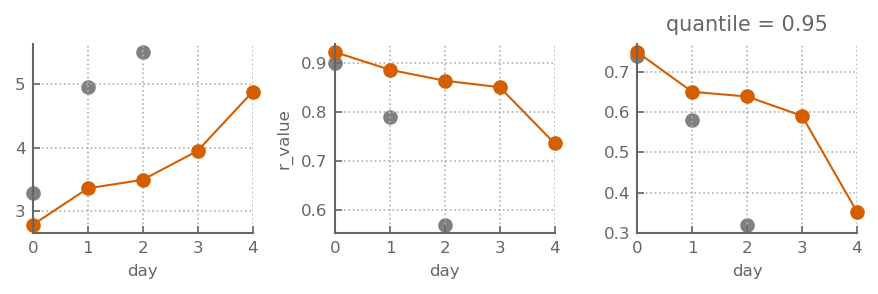

In [ ]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1,3, figsize=(6,2), sharex=True)

rmse.plot(ax=axs[0], marker='o', color='C3', clip_on=False)
r_value.plot(ax=axs[1], marker='o', color='C3',clip_on=False)
f1.plot(ax=axs[2], marker='o', color='C3',clip_on=False)

axs[0].scatter([0,1,2],[3.28,4.95, 5.5], color='.5',clip_on=False)
axs[1].scatter([0,1,2],[0.90, 0.79, 0.57], color='.5',clip_on=False)
axs[2].scatter([0,1,2],[0.74, 0.58, 0.32], color='.5',clip_on=False)

for ax in axs:
    ax.grid(zorder=0)
    ax.set_xlim(0,4)
axs[0].set_title()

plt.tight_layout()


In [ ]:
pred_over_95 = (preds>q95.rename(target_day='day')).count('time')


<xarray.DataArray (day: 5)> Size: 40B
array([4601, 4601, 4601, 4601, 4601])
Coordinates:
    quantile  float64 8B 0.95
Dimensions without coordinates: day

In [72]:
q95 = q95.rename(day='target_day')

In [64]:
ds.to_netcdf('attributions_best_model_5days.nc')

In [87]:
ds_mean.attributions.sum(['longitude','latitude']).plot.area(row='target_day', hue='var_name')

AttributeError: 'DataArrayPlotAccessor' object has no attribute 'area'

In [73]:
ds_mean = ds.where((ds.preds>q95)&(ds.targets>q95)).mean('time')
ds_count = ds.preds.where((ds.preds>q95)&(ds.targets>q95)).count('time')

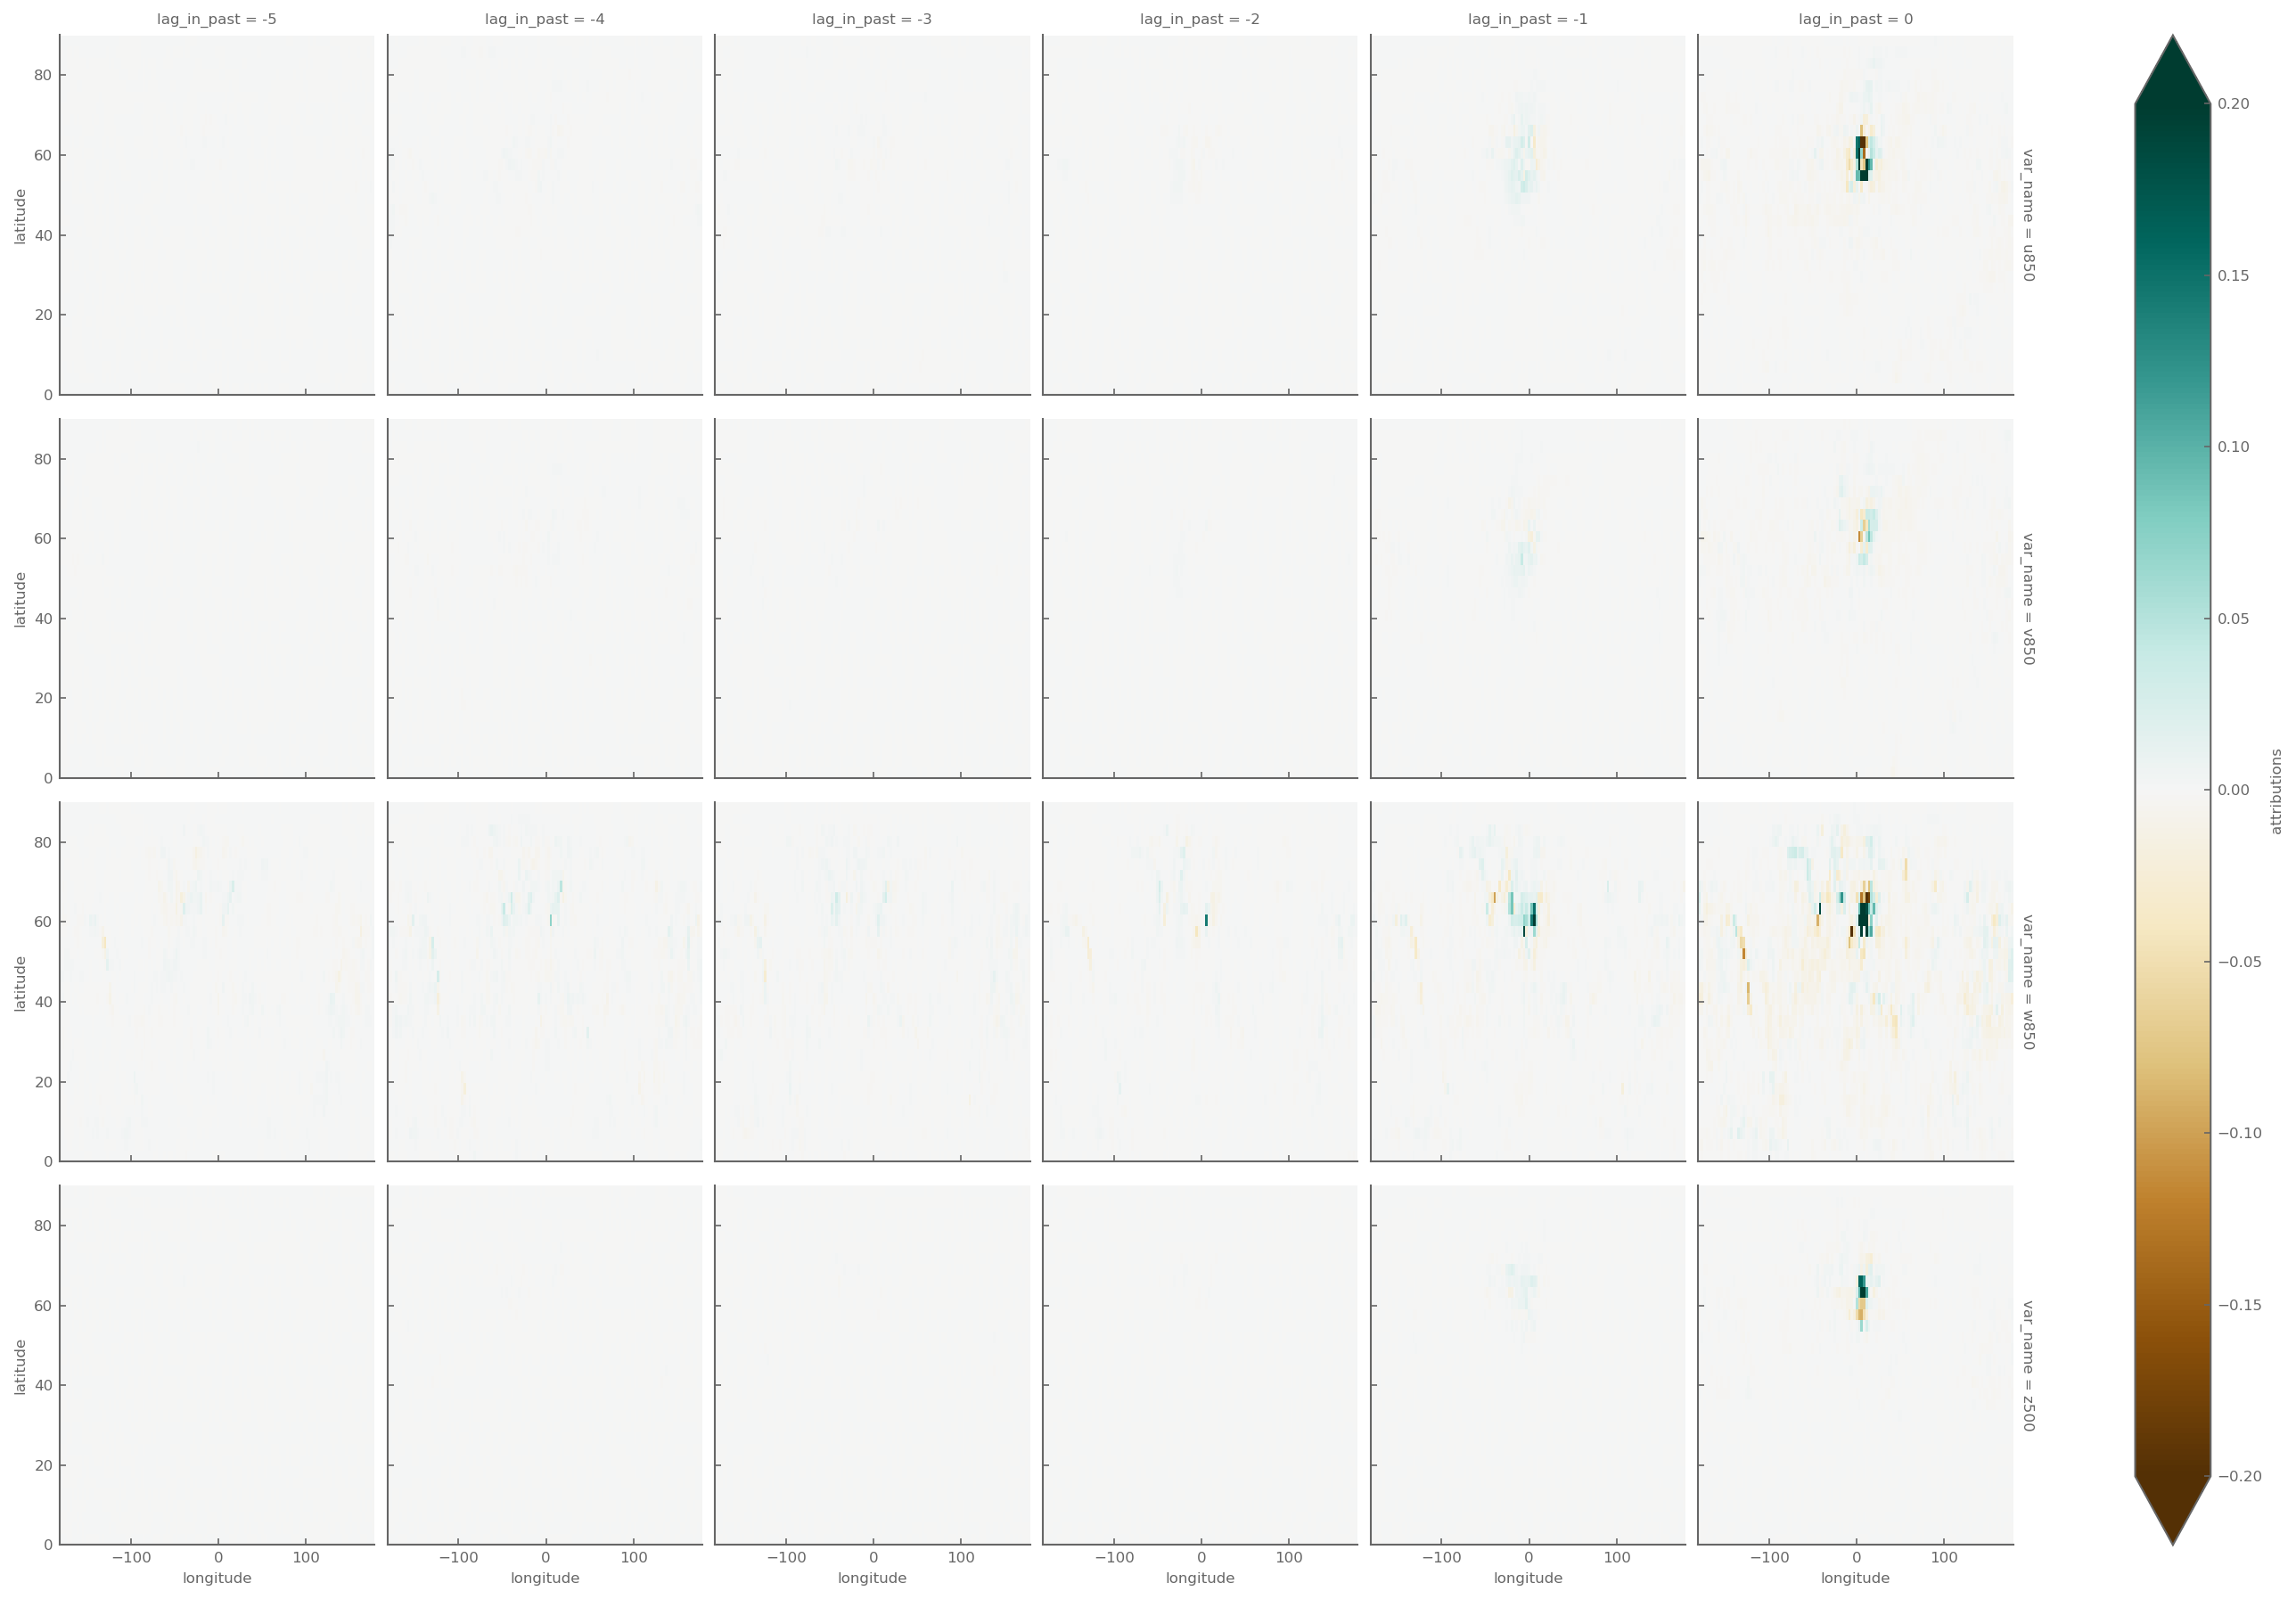

In [86]:
ds_mean.attributions.isel(target_day=0).plot(col='lag_in_past', row='var_name', vmax=.2, cmap='BrBG')

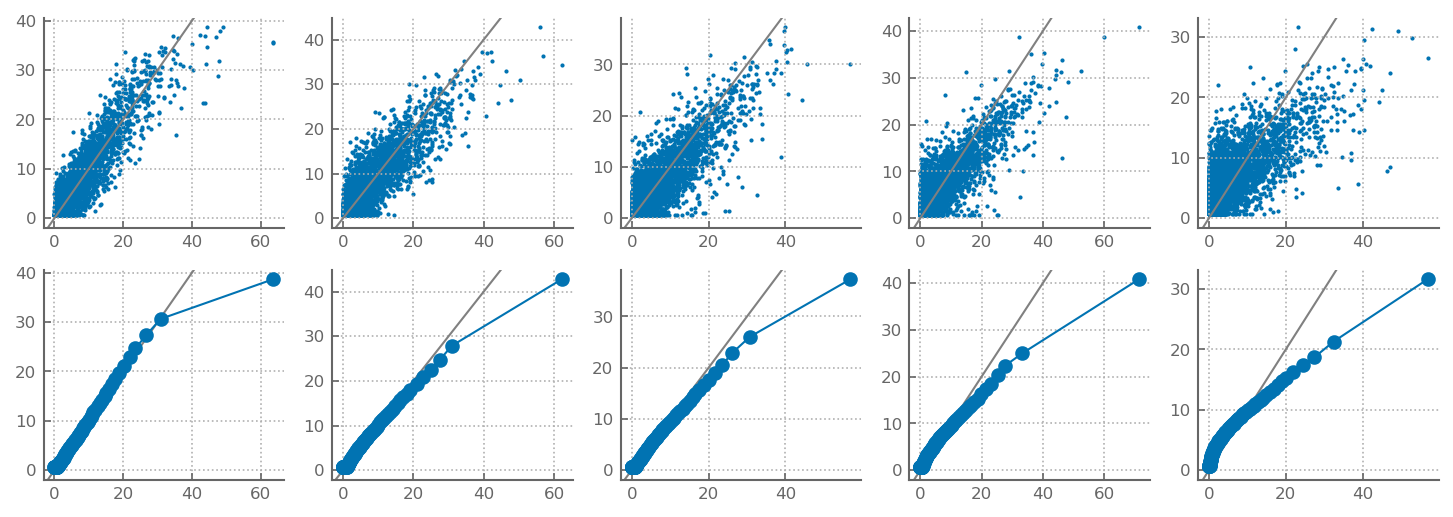

In [6]:
import matplotlib.pyplot as plt
plt.style.use('robin')

fig, axs = plt.subplots(2,5,figsize=(12,4))
for k in range(5):
    axs[0,k].scatter(targets.isel(day=k), preds.isel(day=k), s=1)
    axs[0,k].grid()
    axs[0,k].axline((0,0), slope=1, color='.5')
    axs[1,k].grid()
    axs[1,k].axline((0,0), slope=1, color='.5')
    axs[1,k].plot(targets.isel(day=k).quantile(np.arange(0,1.01,.01)), preds.isel(day=k).quantile(np.arange(0,1.01,.01)), marker='o')

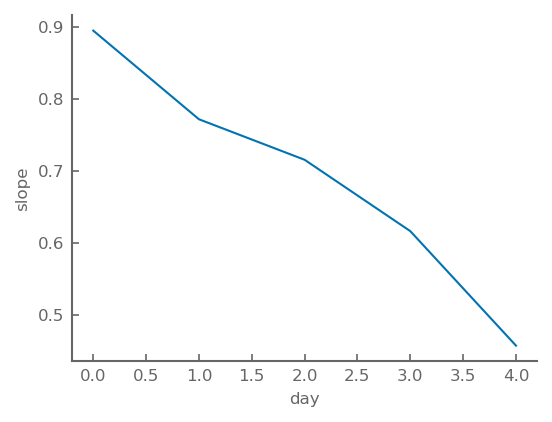

In [37]:
from xarrayutils import xr_linregress
regr = xr_linregress(targets, preds)
regr.slope.plot()

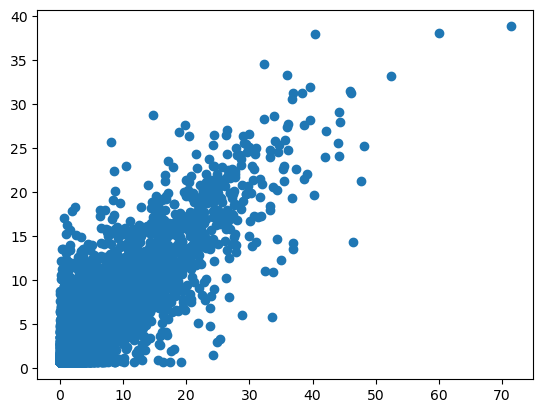

In [16]:
from xarrayutils import xr_linregress
regr = xr_linregress(targets, preds)
regr

<xarray.Dataset> Size: 120B
Dimensions:    (day: 3)
Dimensions without coordinates: day
Data variables:
    slope      (day) float64 24B 0.8742 0.6746 0.4219
    intercept  (day) float64 24B 1.645 1.982 3.351
    r_value    (day) float64 24B 0.9034 0.8018 0.6021
    p_value    (day) float64 24B 0.0 0.0 0.0
    std_err    (day) float64 24B 0.00612 0.007414 0.008249

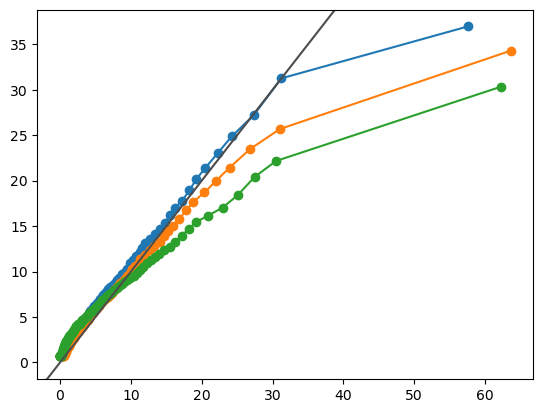

In [19]:
for k in range(3):
    plt.plot(quantiles.isel(day=k), quantiles_pred.isel(day=k), marker='o')
plt.axline((0,0), slope=1, color='.3')

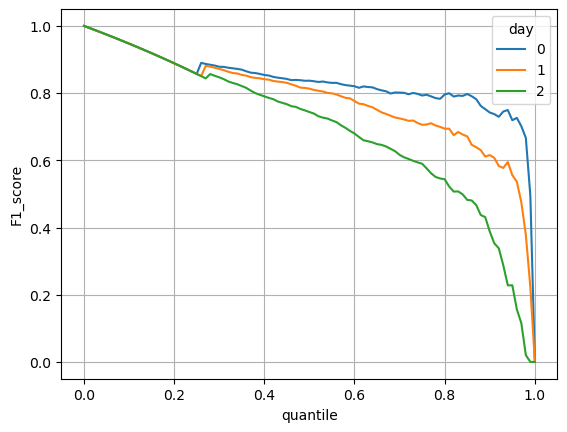

In [20]:
f1.plot(hue='day')
plt.grid()


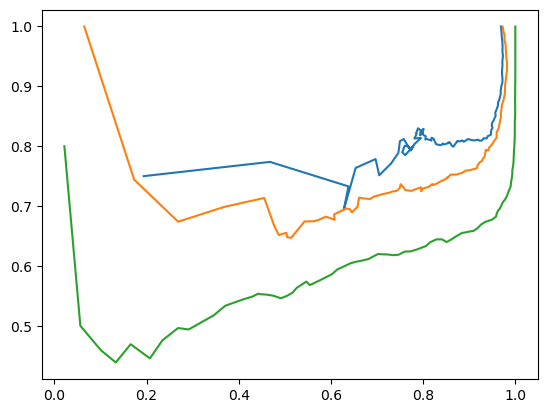

In [41]:
import matplotlib.pyplot as plt
plt.plot(recall.isel(day=0), precision.isel(day=0))
plt.plot(recall.isel(day=1), precision.isel(day=1))
plt.plot(recall.isel(day=2), precision.isel(day=2))

In [2]:
import xarray as xr
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset, random_split
from torch.utils.data import Dataset

In [4]:
input_variable = ['u850','v850']
region_predicted = 14
type_prediction = 'regression'
batch_size = 256
augment_train_set = False
n_days_predictant=3
n_days_predicted=5
lags=0

In [3]:

ds_in = xr.open_dataset('/Data/gfi/users/rogui7909/data/ERA5/dl_inputs_32x64.nc').data_normed.load()
variables = {str(ds_in.var_name.values[k]):k for k in range(ds_in.var_name.size)}
ds_in = ds_in.sel(var_name=input_variable)
input_indices = [variables[k] for k in input_variable]
data_in = np.load('/Data/gfi/users/rogui7909/data/ERA5/dl_inputs_32x64.npy')[:,input_indices]
tensor_in = torch.Tensor(data_in).type(torch.float32)


In [84]:

def get_input_data_small_extended_multidays(
        input_variable, region_predicted, type_prediction, batch_size,
        augment_train_set = False, n_days_predictant=1, n_days_predicted=1,
        lags=0):
    ds_in = xr.open_dataset('/Data/gfi/users/rogui7909/data/ERA5/dl_inputs_32x64.nc').data_normed.load().sel(var_name=input_variable)
    all_shifts = []
    for k in range(n_days_predictant):
        ds_shift = ds_in.shift(time=k)
        ds_shift = ds_shift.assign_coords(lag=f"lag{k}" )
        all_shifts.append(ds_shift)
    ds_shift = xr.concat(all_shifts[::-1], dim='lag')
    gradients = ds_shift.diff('lag').assign_coords(lag=[f"Grad{k+1}-{k}" for k in range(n_days_predictant-1)][::-1])
    ds_shift_grad = xr.concat([ds_shift, gradients], dim='lag')
    ds_shift_grad = ds_shift_grad.stack(features=['var_name','lag']).transpose('time','features','latitude','longitude')
    values_features = ds_shift_grad.values
    tensor_in = torch.Tensor(values_features).type(torch.float32)

    with xr.open_dataarray('/Data/gfi/users/rogui7909/era5_rain_norge/ERA5land_daily_TP_indices.nc', chunks = dict(longitude=20, latitude=20, var_name=0)) as ds_out:
        data_out = ds_out.sel(mask_id=region_predicted)
        if type_prediction=='quantiles':
            data_out = (data_out.rank('time', pct=True)//.1).astype(int)
        all_out_shift = []
        for k in range(n_days_predicted):
            data_out_shift = data_out.shift(time=-k).assign_coords(lag=f"day+{k}")
            all_out_shift.append(data_out_shift)
        data_out_shifts = xr.concat(all_out_shift, dim='lag')
        data_out_values = data_out_shifts.values
    tensor_out = torch.Tensor(data_out_values).type(torch.float32).T

    tensor_in = tensor_in[n_days_predictant:-n_days_predicted]
    tensor_out = tensor_out[n_days_predictant:-n_days_predicted]
    if lags!=0:
        tensor_in = tensor_in[:-lags]
        tensor_out = tensor_out[lags:]
    dataset = TensorDataset(tensor_in, tensor_out)

    # use 20% of data for test
    trainvalid_set_size = int(len(dataset) * 0.8)
    test_set_size = len(dataset) - trainvalid_set_size
    # split the train set into two
    seed = torch.Generator().manual_seed(42)
    trainvalid_set, test_set = random_split(dataset, [trainvalid_set_size, test_set_size], generator=seed)

    # use 20% of training data for validation
    train_set_size = int(len(trainvalid_set) * 0.8)
    valid_set_size = len(trainvalid_set) - train_set_size

    # split the train set into two
    seed = torch.Generator().manual_seed(43)
    train_set, valid_set = random_split(trainvalid_set, [train_set_size, valid_set_size], generator=seed)
    # if augment_train_set:
    #     train_set = AugmentedRainfallDataset(train_set, threshold=30.0, noise_std=0.01, augment_factor=1)

    train_loader = DataLoader(train_set, batch_size=batch_size)
    valid_loader = DataLoader(valid_set, batch_size=batch_size)
    test_loader = DataLoader(test_set, batch_size=batch_size)

    ds_test = ds_shift_grad.shift(time=lags).isel(time=test_loader.dataset.indices)

    return train_loader, valid_loader, test_loader, ds_test

In [97]:
train_loader, valid_loader, test_loader, ds_test = get_input_data_small_extended_multidays(input_variable, region_predicted, type_prediction, batch_size, n_days_predictant=3, n_days_predicted=5, lags=2)

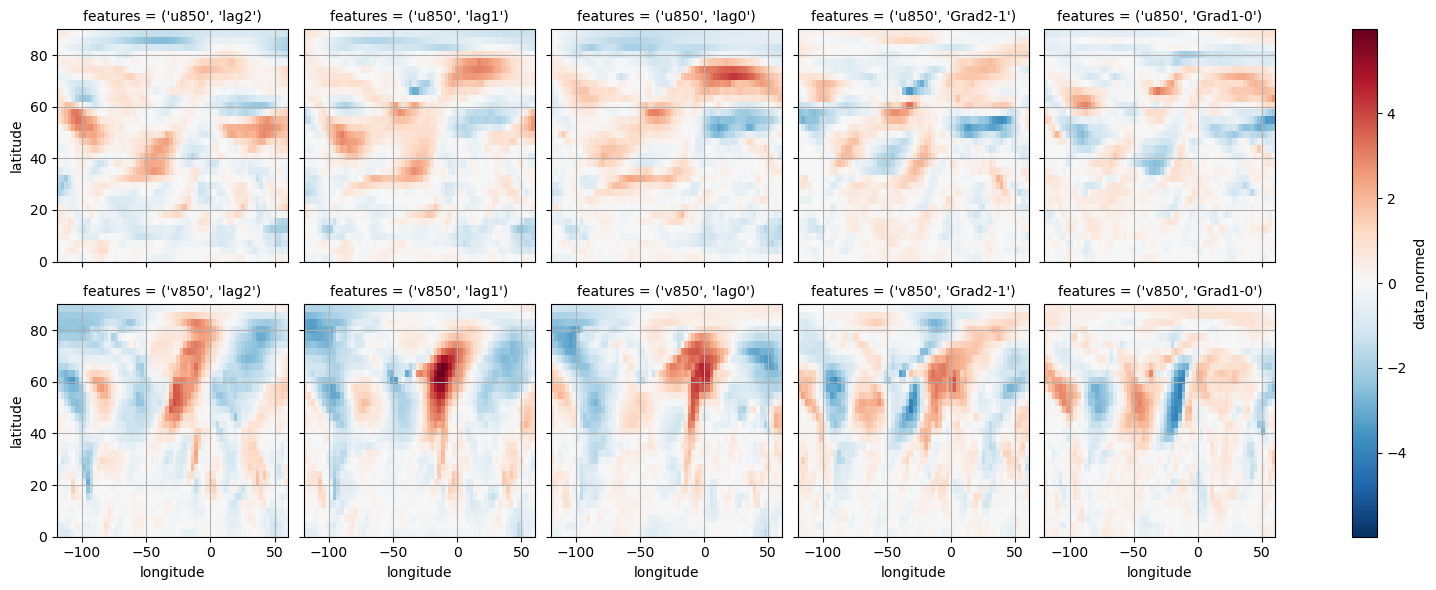

In [99]:
plot = ds_test.isel(time=0).plot(col='features',col_wrap=5)
for ax in plot.axs.flatten():
    ax.grid()

In [1]:
print('Running imports...')

import torch # long
import os
import numpy as np
import lightning as L
from torch.utils.data import DataLoader, TensorDataset, random_split
import xarray as xr
from models.model import Wang2024
from lightning.pytorch.loggers import WandbLogger
from lightning.pytorch import seed_everything
import wandb
from models.lightning import LitCNN_regression, AttributableTrainer, LogPlotsRegression
from models.losses import get_loss
import random
import matplotlib
from models.data import get_input_data, get_input_data_small,get_input_data_small_extended,get_input_data_small_extended_multidays
import pandas as pd
import cartopy.crs as ccrs
from models.attributions import log_attribution_regression
import argparse

Running imports...


In [2]:
    attribute_test = False
    wandb_logger = WandbLogger(project="Predict-rain-WNorway_multidays", 
                               save_dir="/Data/gfi/users/rogui7909/wanbd_logs/",
                               dir="/Data/gfi/users/rogui7909/wanbd_logs/wandb", )

    # wandb_logger.experiment # Initialize wandb

    # train_loader, valid_loader, test_loader, ds_test = get_input_data_small_extended(input_variable=wandb_logger.experiment.config['input_variable'], 
    #                                                                                 region_predicted=14,
    #                                                                                 type_prediction='regression', 
    #                                                                                 batch_size=wandb_logger.experiment.config['batch_size'], 
    #                                                                                 lags=wandb_logger.experiment.config['lags'], 
    #                                                                                 augment_train_set=False)
    train_loader, valid_loader, test_loader, ds_test = get_input_data_small_extended_multidays(
                        input_variable=wandb_logger.experiment.config['input_variable'], 
                        region_predicted=14,
                        type_prediction='regression', 
                        batch_size=wandb_logger.experiment.config['batch_size'], 
                        lags=wandb_logger.experiment.config['lags'], 
                        augment_train_set=False,
                        n_days_predictant=wandb_logger.experiment.config['num_days_predictant'], 
                        n_days_predicted=wandb_logger.experiment.config['num_days_predicted'],
                        include_gradients=wandb_logger.experiment.config['include_gradient_features'],)

    image_size = train_loader.dataset.dataset.dataset.tensors[0].shape[-1]*train_loader.dataset.dataset.dataset.tensors[0].shape[-2]

    print('Data ready')

    callbacks=[]

    trainer = AttributableTrainer(limit_train_batches=100, max_epochs=wandb_logger.experiment.config['num_epochs'], 
                                logger=wandb_logger, 
                                log_every_n_steps=1, default_root_dir="/Data/gfi/users/rogui7909/lightning_checkpoint/",
                                callbacks=callbacks, deterministic=True,
                                accelerator="gpu", devices=1,
                                gradient_clip_val=wandb_logger.experiment.config['gradient_clip_val'])

    num_classes = wandb_logger.experiment.config['num_days_predicted']
    num_output_neurons = num_classes

    CNN = Wang2024(num_classes=num_output_neurons, 
                num_channels_in=ds_test.features.size, 
                image_size=image_size, 
                groups=len(wandb_logger.experiment.config['input_variable']),
                size_conv1_kernel=wandb_logger.experiment.config['conv1_kernel_size'],
                size_conv2_kernel=wandb_logger.experiment.config['conv2_kernel_size'],
                out_channels_conv1=wandb_logger.experiment.config['conv1_kernel_number'],
                out_channels_conv2=wandb_logger.experiment.config['conv2_kernel_number'],
                dropout_proba=wandb_logger.experiment.config['dropout_proba'],)


    loss = get_loss(wandb_logger.experiment.config['loss_fn'])


    model = LitCNN_regression(CNN, 
                            learning_rate=wandb_logger.experiment.config['learning_rate'], 
                            loss_fn = loss)

    print('Model init')
    trainer.fit(model, train_loader, valid_loader)


    model.eval()
    with torch.no_grad():
        trainer.test(model, dataloaders=test_loader)

wandb: Currently logged in as: rguilcas (rguilcas-university-of-bergen) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: Using wandb-core as the SDK backend.  Please refer to https://wandb.me/wandb-core for more information.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Data ready
Model init


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name    | Type              | Params | Mode 
------------------------------------------------------
0 | model   | Wang2024          | 759 K  | train
1 | loss_fn | AsymmetricMSELoss | 0      | train
------------------------------------------------------
759 K     Trainable params
0         Non-trainable params
759 K     Total params
3.040     Total estimated model params size (MB)
12        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=20` reached.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/felles_gfi/felles_gfi_users/rogui7909/miniforge3/envs/robin/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=71` in the `DataLoader` to improve performance.


Testing: |          | 0/? [00:00<?, ?it/s]

────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
       Test metric             DataLoader 0
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
        test/loss            36.38706588745117
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────


In [3]:
min_rain = 0
from captum.attr import IntegratedGradients

truth = torch.stack(model.test_true_values).cpu().numpy()
pred = torch.stack(model.test_pred).cpu().numpy()

# true_indices = np.where((truth>=min_rain)&(pred>=min_rain))[0]
# data_in_true_target = torch.cat([batch[0] for batch in test_loader])[true_indices]
# data_out_true_target = torch.Tensor(pred[true_indices])
# dataset_attr = TensorDataset(data_in_true_target,data_out_true_target)
# attribution_loader = DataLoader(dataset_attr, batch_size=10)
attribution_loader = test_loader
baseline = torch.stack([torch.cat([torch.zeros_like(batch[0]) for batch in test_loader]).mean(dim=0)])
ig = IntegratedGradients(trainer.model.model)
# dl = DeepLift(trainer.model.model)
all_attr = []
for target_day in range(wandb_logger.experiment.config['num_days_predicted']):
    attribution_ig = trainer.attribute(attribution_loader, baselines=baseline, target=target_day, attribution_method=ig)
    # attribution_nt = trainer.attribute(attribution_loader, baselines=baseline, target=0, attribution_method=nt)
    # attribution_dl = trainer.attribute(attribution_loader, baselines=baseline, target=0, attribution_method=dl)

    attribution_da = xr.DataArray([attribution_ig], 
                                dims=['attr_method']+list(ds_test.dims), 
                                coords={'attr_method':['IntegratedGradients', 
                                                    #    'IntegratedGradients+NoiseTunnel'
                                                        ], 
                                        **ds_test.coords})
    pred_da = xr.DataArray(pred[:,target_day], dims=['time'], coords=dict(time=attribution_da.time))
    truth_da = xr.DataArray(truth[:,target_day], dims=['time'], coords=dict(time=attribution_da.time))

    ds_attr = xr.Dataset(dict(data = ds_test-ds_test.mean('time'),
                                attributions = attribution_da,
                                pred=pred_da, truth = truth_da))#.sortby('time').assign_coords(min_rain=min_rain)
    all_attr.append(ds_attr.assign_coords(target_day=target_day))
ds = xr.concat(all_attr, dim='target_day')
# ds_attr.attrs['baseline_prediction'] = trainer.model(baseline).detach().numpy().squeeze()

Computing Attributions: 100%|██████████| 9/9 [03:56<00:00, 26.30s/it]


In [ ]:
ds_mean_over20_mean = ds.where((((ds.pred>20)&(ds.truth>20)))).attributions.mean('time')

,target_day,attr_method,time,var_name,lag,attributions
0,0,IntegratedGradients,1988-04-28,u850,lag2,0.0
1,0,IntegratedGradients,1988-04-28,u850,lag1,0.0
2,0,IntegratedGradients,1988-04-28,u850,lag0,0.0
3,0,IntegratedGradients,1988-04-28,u850,Grad2-1,0.0
4,0,IntegratedGradients,1988-04-28,u850,Grad1-0,0.0
...,...,...,...,...,...,...
207040,2,IntegratedGradients,2019-11-12,z500,lag2,0.0
207041,2,IntegratedGradients,2019-11-12,z500,lag1,0.0
207042,2,IntegratedGradients,2019-11-12,z500,lag0,0.0
207043,2,IntegratedGradients,2019-11-12,z500,Grad2-1,0.0


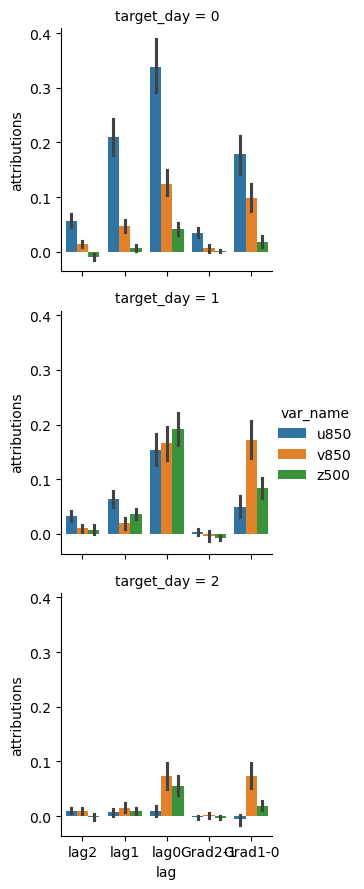

In [26]:
df_ = ds_mean_over20_mean.sum(['longitude','latitude']).to_series().reset_index()
import seaborn as sns
sns.catplot(df_, x='lag', hue='var_name', y='attributions', row='target_day', height=3, kind='bar')
df_

In [5]:
ds_mean_over20 = ds.where((((ds.pred>20)&(ds.truth>20))|((ds.pred<20)&(ds.truth<20))).sum('target_day')==3, drop=True)
ds_mean_over20

<xarray.Dataset> Size: 4GB
Dimensions:       (target_day: 3, time: 4014, features: 15, latitude: 32,
                   longitude: 64, attr_method: 1)
Coordinates:
  * latitude      (latitude) float64 256B 1.406 4.219 7.031 ... 85.78 88.59
  * longitude     (longitude) float64 512B -118.1 -115.3 -112.5 ... 56.25 59.06
  * time          (time) datetime64[ns] 32kB 1988-04-28 ... 2019-11-12
  * features      (features) object 120B MultiIndex
  * var_name      (features) <U4 240B 'u850' 'u850' 'u850' ... 'z500' 'z500'
  * lag           (features) <U7 420B 'lag2' 'lag1' ... 'Grad2-1' 'Grad1-0'
  * attr_method   (attr_method) <U19 76B 'IntegratedGradients'
  * target_day    (target_day) int64 24B 0 1 2
Data variables:
    data          (target_day, time, features, latitude, longitude) float32 1GB ...
    attributions  (target_day, attr_method, time, features, latitude, longitude) float64 3GB ...
    pred          (target_day, time) float32 48kB 1.898 17.11 ... 2.901 0.6925
    truth         (target_day, time) float32 48kB 0.955 15.32 ... 13.38 0.4665

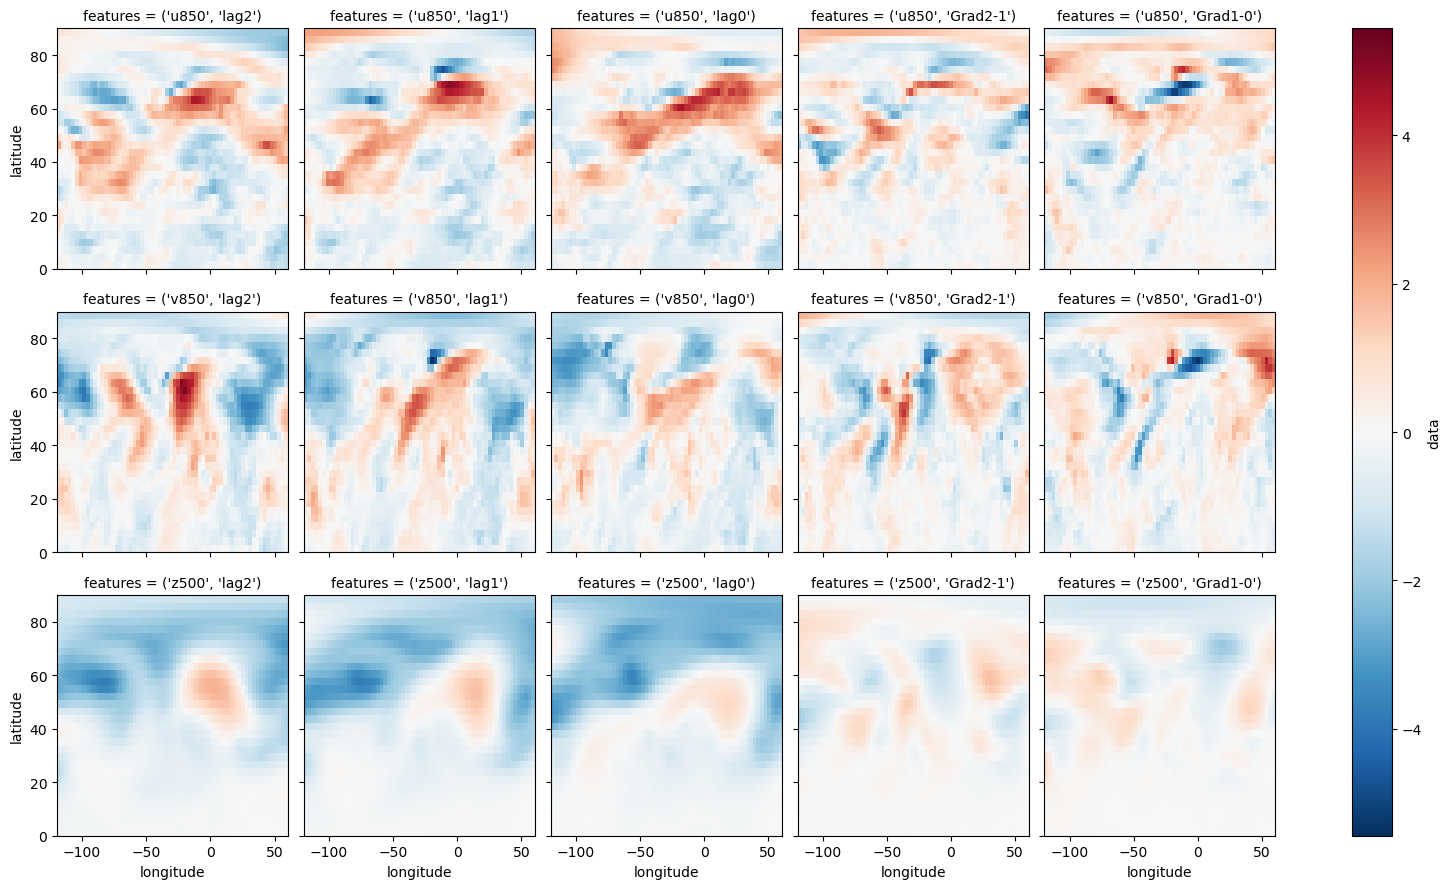

In [15]:
ds_mean_over20.isel(time=0, target_day=2).data.plot(col='features', col_wrap=5)

In [ ]:
ds_mean_over20.mean('time').attributions.sum(['longitude','latitude']).to_series().unstack().T.plot.bar()

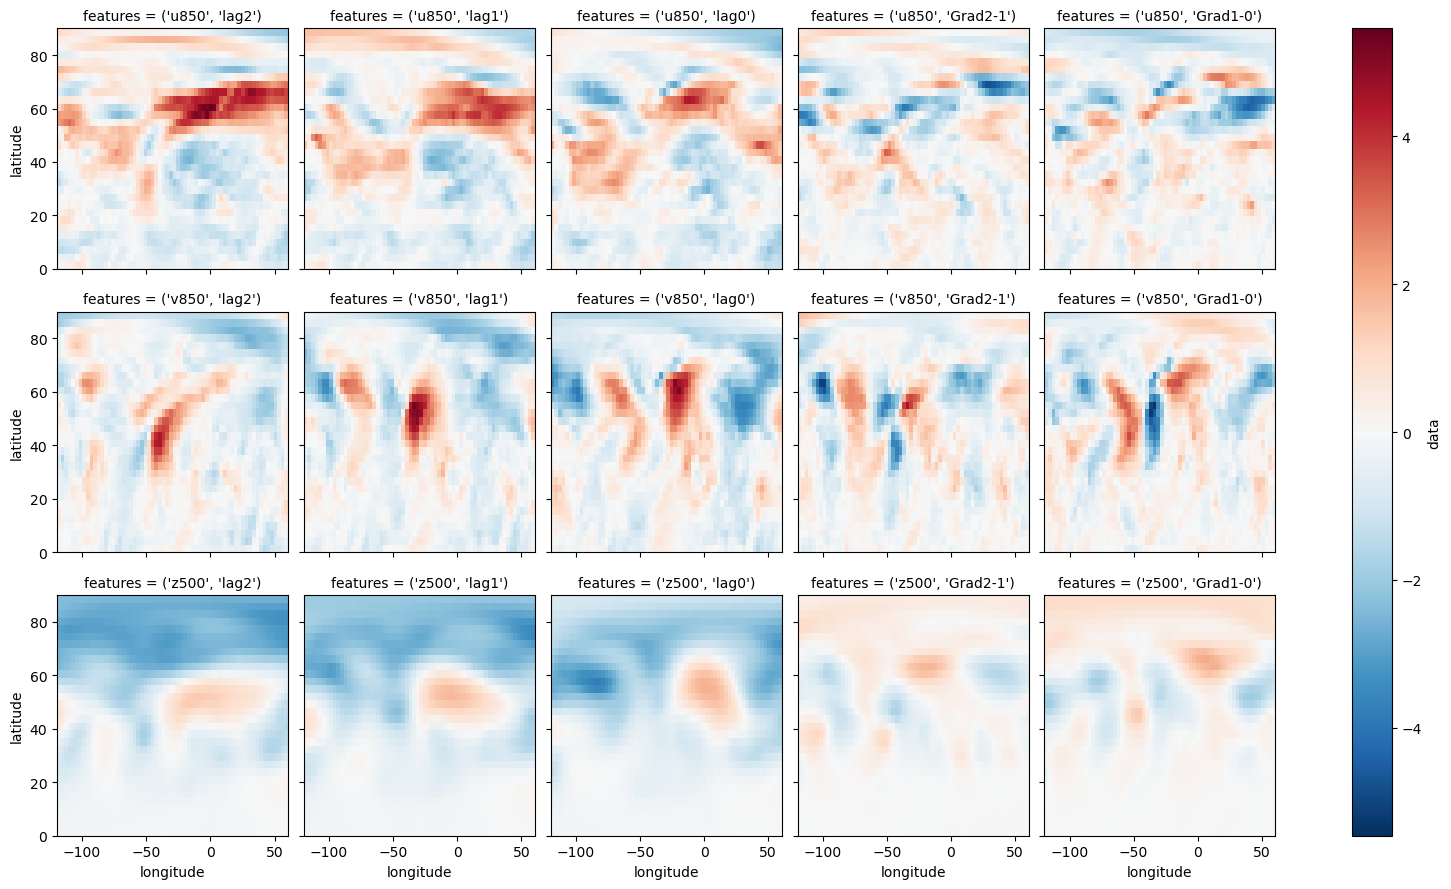

wandb: 
wandb: 🚀 View run noble-armadillo-10 at: https://wandb.ai/rguilcas-university-of-bergen/Predict-rain-WNorway_multidays/runs/inzy56mb
wandb: Find logs at: ../../../../../../Data/gfi/users/rogui7909/wanbd_logs/wandb/run-20250317_121237-inzy56mb/logs


In [10]:
ds_mean_over20.isel(time=0).data.plot(col='features', col_wrap=5)

In [21]:
df_ = ds_mean_over20_mean.sum(['longitude','latitude']).to_series().reset_index()
import seaborn as sns
sns.catplot(df_, x='lag', hue='var_name', col='time', y='attributions', row='target_day', height=3, kind='bar')
df_

ValueError: Could not interpret value `attributions` for `y`. An entry with this name does not appear in `data`.

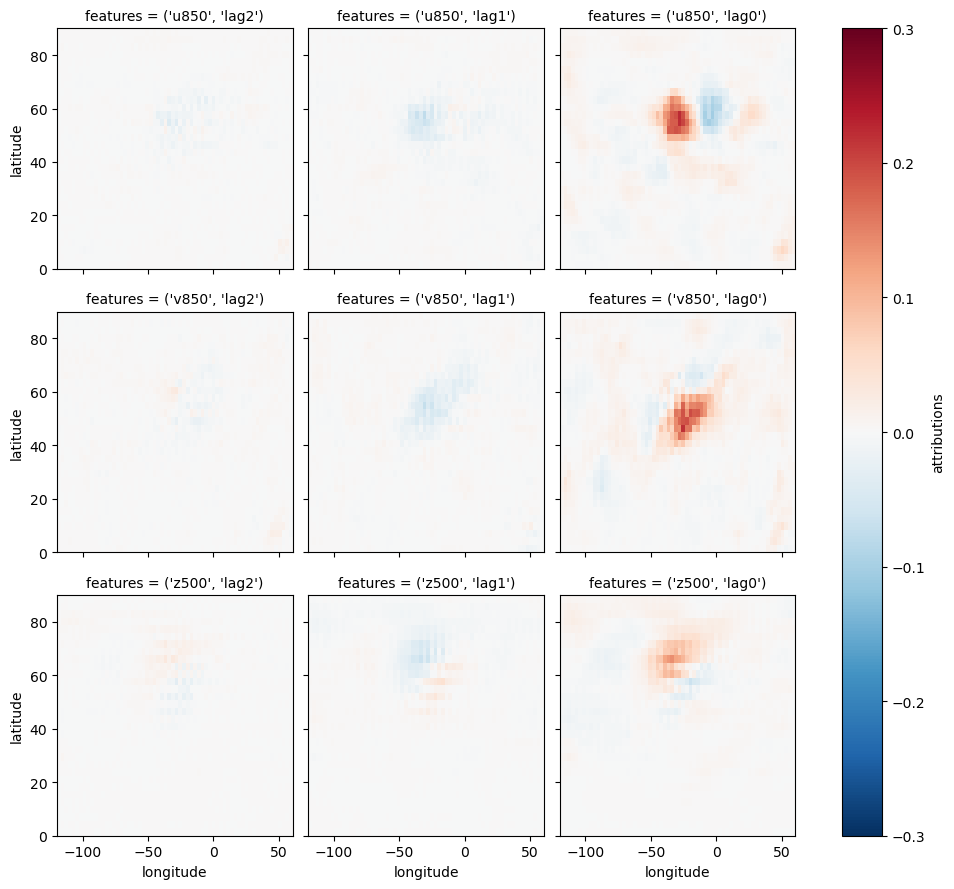

In [10]:
ds_mean_over20.attributions.sel(target_day=2).plot(col='features', col_wrap=3, vmax=0.3)

In [13]:
for target_day in range(2,wandb_logger.experiment.config['num_days_predicted']):
    attribution_ig = trainer.attribute(attribution_loader, baselines=baseline, target=target_day, attribution_method=ig)
    # attribution_nt = trainer.attribute(attribution_loader, baselines=baseline, target=0, attribution_method=nt)
    # attribution_dl = trainer.attribute(attribution_loader, baselines=baseline, target=0, attribution_method=dl)

    attribution_da = xr.DataArray([attribution_ig], 
                                dims=['attr_method']+list(ds_test.dims), 
                                coords={'attr_method':['IntegratedGradients', 
                                                    #    'IntegratedGradients+NoiseTunnel'
                                                        ], 
                                        **ds_test.coords})
    pred_da = xr.DataArray(pred[:,target_day], dims=['time'], coords=dict(time=attribution_da.time))
    truth_da = xr.DataArray(truth[:,target_day], dims=['time'], coords=dict(time=attribution_da.time))

    ds_attr = xr.Dataset(dict(data = ds_test-ds_test.mean('time'),
                                attributions = attribution_da,
                                pred=pred_da, truth = truth_da))#.sortby('time').assign_coords(min_rain=min_rain)
    all_attr.append(ds_attr.assign_coords(target_day=target_day))

Computing Attributions: 100%|██████████| 9/9 [07:27<00:00, 49.70s/it]


In [30]:
ds_mean_over20 = ds.where((ds.pred>20)&(ds.truth>20)).mean('time')

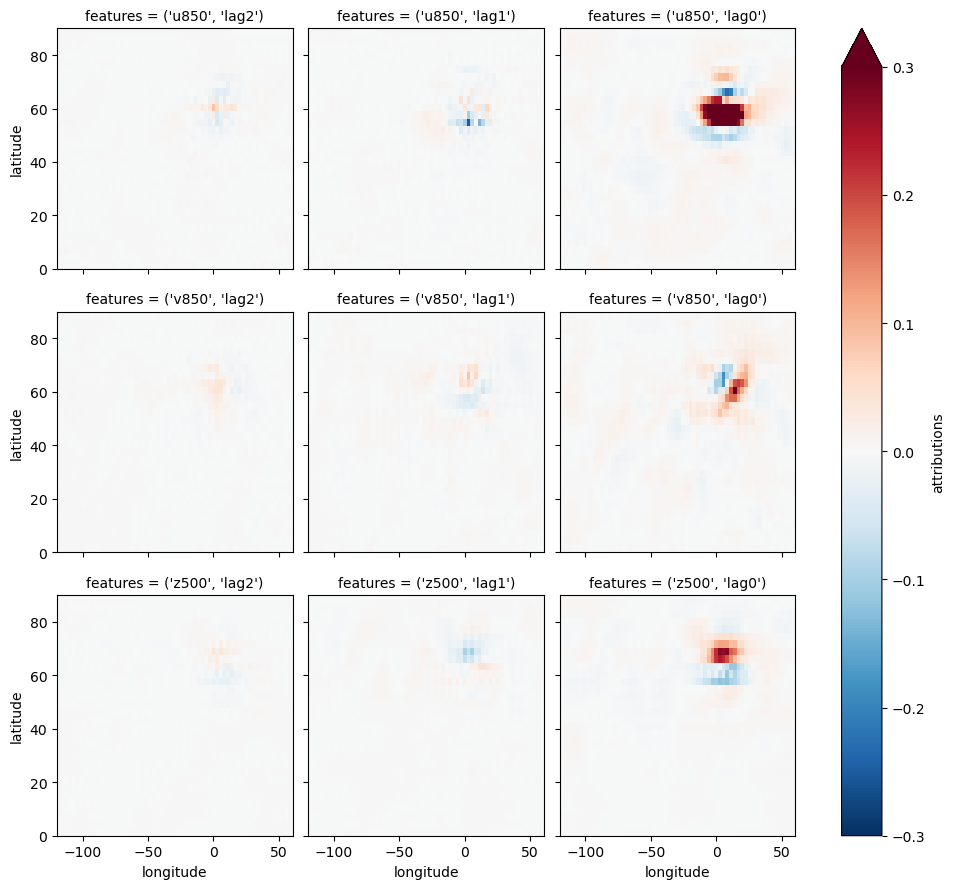

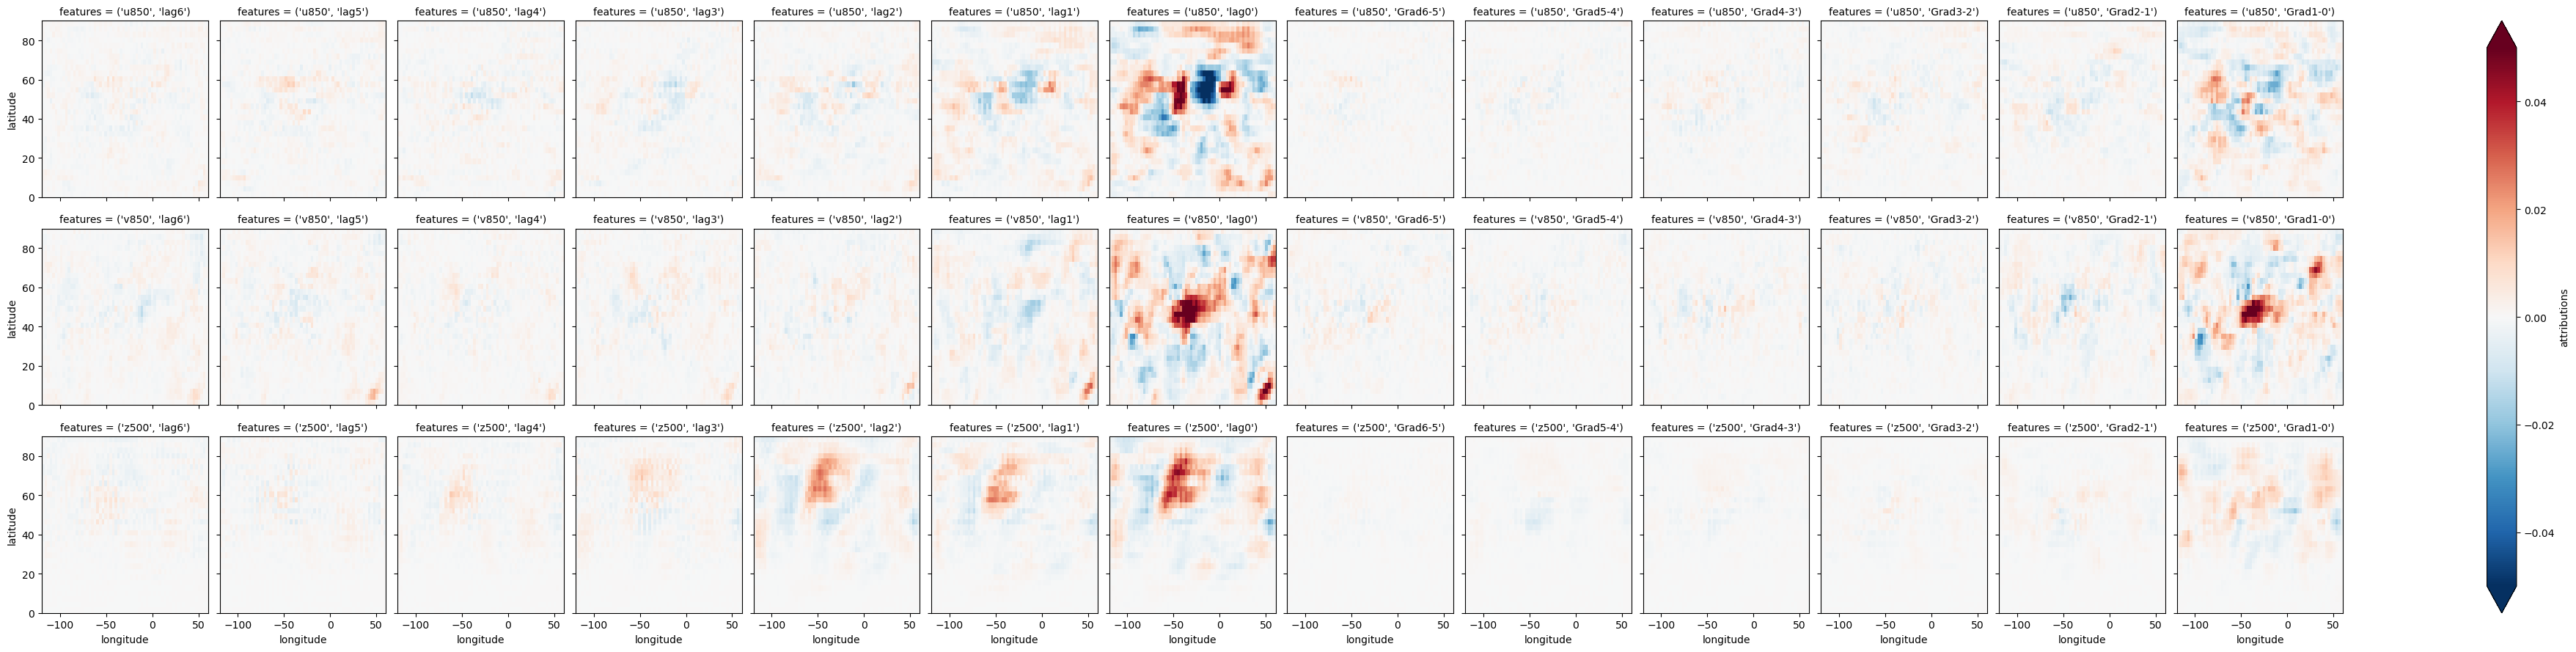

In [43]:
ds_mean_over20.attributions.sel(target_day=3).isel(target_day=0).plot(col='features', col_wrap=13, vmax=0.05)

In [14]:
    pred_da = xr.DataArray(pred[:,target_day], dims=['time'], coords=dict(time=attribution_da.time))
    truth_da = xr.DataArray(truth[:,target_day], dims=['time'], coords=dict(time=attribution_da.time))

    ds_attr = xr.Dataset(dict(data = ds_test-ds_test.mean('time'),
                                attributions = attribution_da,
                                pred=pred_da, truth = truth_da))
    all_attr.append(ds_attr.assign_coords(target_day=target_day))

In [ ]:
print('Computing attributions...')
ds_attr = trainer.get_multi_attribution_ds_regr(test_loader, ds_test, min_rain=0)

In [27]:
truth = torch.stack(model.test_true_values).cpu().numpy()
pred = torch.stack(model.test_pred).cpu().numpy()

In [31]:
df_truth = pd.DataFrame(truth, columns=[f"truth_day{k}" for k in range(pred.shape[1])])
df_pred = pd.DataFrame(pred, columns=[f"pred_day{k}" for k in range(pred.shape[1])])
df_all = pd.concat([df_truth, df_pred], axis=1)

In [ ]:
df_all..tran

,truth_day0,truth_day1,truth_day2,pred_day0,pred_day1,pred_day2
truth_day0,1.000000,0.514463,0.304288,0.882239,0.598427,0.382651
truth_day1,0.514463,1.000000,0.487969,0.551428,0.792390,0.584343
truth_day2,0.304288,0.487969,1.000000,0.337869,0.536573,0.584236
pred_day0,0.882239,0.551428,0.337869,1.000000,0.665989,0.419997
pred_day1,0.598427,0.792390,0.536573,0.665989,1.000000,0.766892
pred_day2,0.382651,0.584343,0.584236,0.419997,0.766892,1.000000


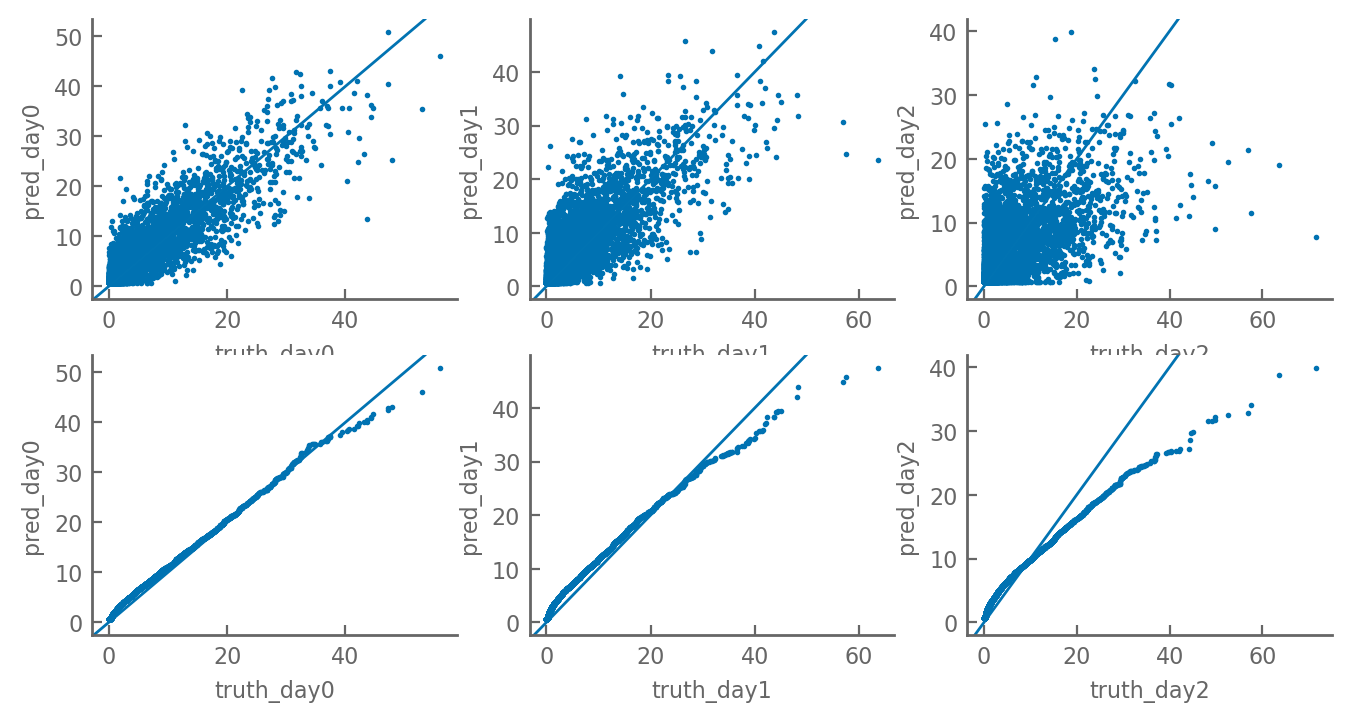

In [36]:
import matplotlib.pyplot as plt
plt.style.use('robin')
fig, axs = plt.subplots(2,3,figsize=(8,4), dpi=200)

df_all.plot.scatter(x='truth_day0', y='pred_day0', ax=axs[0,0], s=1)
df_all.plot.scatter(x='truth_day1', y='pred_day1', ax=axs[0,1], s=1)
df_all.plot.scatter(x='truth_day2', y='pred_day2', ax=axs[0,2], s=1)

df_all.transform(np.sort).plot.scatter(x='truth_day0', y='pred_day0', ax=axs[1,0], s=1)
df_all.transform(np.sort).plot.scatter(x='truth_day1', y='pred_day1', ax=axs[1,1], s=1)
df_all.transform(np.sort).plot.scatter(x='truth_day2', y='pred_day2', ax=axs[1,2], s=1)
for ax in axs.flatten():
    ax.axline((0,0), slope=1)

# df_all.plot.scatter(x='truth_day3', y='pred_day3', ax=axs[3], s=1)
# df_all.plot.scatter(x='truth_day4', y='pred_day4', ax=axs[4], s=1)

In [ ]:

with xr.open_dataarray('/Data/gfi/users/rogui7909/era5_rain_norge/ERA5land_daily_TP_indices.nc', chunks = dict(longitude=20, latitude=20, var_name=0)) as ds_out:
    data_out = ds_out.sel(mask_id=region_predicted)
    if type_prediction=='quantiles':
        data_out = (data_out.rank('time', pct=True)//.1).astype(int)
    data_out = data_out.values
tensor_out = torch.Tensor(data_out).type(torch.float32)
if type_prediction=='quantiles':
    tensor_out = tensor_out.type(torch.long)
elif type_prediction=='regression':
    tensor_out = tensor_out.reshape(-1,1)

if lags!=0:
    tensor_in = tensor_in[:-lags]
    tensor_out = tensor_out[lags:]
dataset = TensorDataset(tensor_in, tensor_out)

# use 20% of data for test
trainvalid_set_size = int(len(dataset) * 0.8)
test_set_size = len(dataset) - trainvalid_set_size
# split the train set into two
seed = torch.Generator().manual_seed(42)
trainvalid_set, test_set = random_split(dataset, [trainvalid_set_size, test_set_size], generator=seed)

# use 20% of training data for validation
train_set_size = int(len(trainvalid_set) * 0.8)
valid_set_size = len(trainvalid_set) - train_set_size

# split the train set into two
seed = torch.Generator().manual_seed(43)
train_set, valid_set = random_split(trainvalid_set, [train_set_size, valid_set_size], generator=seed)
if augment_train_set:
    train_set = AugmentedRainfallDataset(train_set, threshold=30.0, noise_std=0.01, augment_factor=1)

train_loader = DataLoader(train_set, batch_size=batch_size)
valid_loader = DataLoader(valid_set, batch_size=batch_size)
test_loader = DataLoader(test_set, batch_size=batch_size)

ds_test = ds_in.shift(time=lags).isel(time=test_loader.dataset.indices)